https://www.kaggle.com/competitions/playground-series-s6e1

In [1]:
import torch
torch.manual_seed(42)
import os

# === DIRECT KAGGLE CREDENTIALS ===
os.environ['KAGGLE_USERNAME'] = 'asd147'
os.environ['KAGGLE_KEY']     = '6a95e405001115800e2e18044513a965'
# ===================================

# Always download (kaggle will overwrite the zip if it exists)
!kaggle datasets download -d andrewmvd/car-plate-detection

# Force-overwrite when unzipping (-o = overwrite without prompt)
!unzip -q -o car-plate-detection.zip -d ./data

## Clean up
!rm -f car-plate-detection.zip


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/car-plate-detection
License(s): CC0-1.0
100% 203M/203M [00:00<00:00, 219MB/s]

Using device: cuda


##Visualizing Predictions

The model's predictions are visualized on a sample of images from the validation set. This allows for a qualitative assessment of the model's performance by comparing the predicted bounding boxes (red) with the ground-truth bounding boxes (green) on the actual images.

s [6]. Image transformations are applied to resize the images to a uniform size and scale the bounding box coordinates accordingly, which can improve model accuracy [5].

In [2]:
import xml.etree.ElementTree as ET
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms

class PlateDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.img_dir = os.path.join(data_dir, 'images')
        self.ann_dir = os.path.join(data_dir, 'annotations')
        self.transform = transform
        self.image_files = sorted([f for f in os.listdir(self.img_dir) if f.endswith('.png')])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # Load image
        img_name = self.image_files[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        original_w, original_h = image.size

        # Load annotation
        ann_name = img_name.replace('.png', '.xml')
        ann_path = os.path.join(self.ann_dir, ann_name)
        tree = ET.parse(ann_path)
        root = tree.getroot()

        bndbox = root.find('object').find('bndbox')
        xmin = int(bndbox.find('xmin').text)
        ymin = int(bndbox.find('ymin').text)
        xmax = int(bndbox.find('xmax').text)
        ymax = int(bndbox.find('ymax').text)

        bbox = [xmin, ymin, xmax, ymax]

        if self.transform:
            image = self.transform(image)

        # Scale bounding box to match transformed image size (224x224)
        # The coordinates are normalized to be between 0 and 1
        new_bbox = [
            bbox [0] / original_w,
            bbox [1] / original_h,
            bbox [2] / original_w,
            bbox [3] / original_h
        ]

        return image, torch.tensor(new_bbox, dtype=torch.float32)

# Define transformations: resize to 224x224, convert to tensor, and normalize
data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create the full dataset
full_dataset = PlateDataset(data_dir='./data', transform=data_transform)
print(f"Total number of images in the dataset: {len(full_dataset)}")

Total number of images in the dataset: 433


##Splitting Data and Creating DataLoaders
The dataset is divided into training and validation sets. DataLoader instances are then created for each set to manage batching and shuffling of the data during the training phase.

In [3]:
from torch.utils.data import random_split

# Define split sizes
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Split the dataset
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

Training set size: 346
Validation set size: 87


##Model Architecture
A pre-trained ResNet18 model is used as a feature extractor. Its final fully connected layer is replaced with a new linear layer that functions as a regression head, which is a common approach in two-stage detection models [2]. This new head is designed to output four values representing the predicted bounding box coordinates.

In [4]:
import torch.nn as nn
from torchvision import models

def create_model():
    # Load a pre-trained ResNet18 model
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    # Freeze all the parameters in the pre-trained model
    for param in model.parameters():
        param.requires_grad = False

    # Get the number of input features for the classifier
    num_ftrs = model.fc.in_features

    # Replace the final fully connected layer with a new one for bounding box regression
    # The new layer will output 4 values (xmin, ymin, xmax, ymax)
    model.fc = nn.Sequential(
        nn.Linear(num_ftrs, 4),
        nn.Sigmoid() # Use Sigmoid to ensure output is between 0 and 1
    )

    return model

model = create_model()
model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 118MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

##Training the Model
The model is trained using the Mean Squared Error loss function and the Adam optimizer. The training process iterates for a specified number of epochs, calculating the loss on both the training and validation data. The model that achieves the lowest validation loss is saved for later use.

In [5]:
import torch.optim as optim
from tqdm import tqdm

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# Training loop
num_epochs = 50
best_val_loss = float('inf')

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    for images, bboxes in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        images, bboxes = images.to(device), bboxes.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, bboxes)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    train_loss /= len(train_loader.dataset)

    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, bboxes in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
            images, bboxes = images.to(device), bboxes.to(device)
            outputs = model(images)
            loss = criterion(outputs, bboxes)
            val_loss += loss.item() * images.size(0)

    val_loss /= len(val_loader.dataset)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    # Save the model with the best validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"Model saved with new best validation loss: {best_val_loss:.4f}")

# Load the best model for evaluation
model.load_state_dict(torch.load('best_model.pth'))
print("\nLoaded best model for evaluation.")

Epoch 1/50 [Val]: 100%|██████████| 3/3 [00:01<00:00,  2.25it/s]


Epoch 1/50, Train Loss: 0.0433, Val Loss: 0.0314
Model saved with new best validation loss: 0.0314


Epoch 2/50 [Val]: 100%|██████████| 3/3 [00:01<00:00,  2.27it/s]


Epoch 2/50, Train Loss: 0.0329, Val Loss: 0.0266
Model saved with new best validation loss: 0.0266


Epoch 3/50 [Val]: 100%|██████████| 3/3 [00:01<00:00,  2.26it/s]


...

Epoch 48/50, Train Loss: 0.0094, Val Loss: 0.0188


Epoch 49/50 [Val]: 100%|██████████| 3/3 [00:01<00:00,  2.31it/s]


Epoch 49/50, Train Loss: 0.0098, Val Loss: 0.0191


Epoch 50/50 [Val]: 100%|██████████| 3/3 [00:01<00:00,  2.33it/s]

Epoch 50/50, Train Loss: 0.0098, Val Loss: 0.0190

Loaded best model for evaluation.


##Performance Evaluation with Intersection over Union (IoU)
The model's performance is evaluated using the Intersection over Union (IoU) metric. IoU is a standard metric for object detection that measures the overlap between the predicted and ground-truth bounding boxes. A function is defined to calculate the average IoU score across the entire validation set.

In [6]:
def calculate_iou(box1, box2):
    # box format: [xmin, ymin, xmax, ymax]

    # Calculate intersection coordinates
    inter_xmin = torch.max(box1[:, 0], box2[:, 0])
    inter_ymin = torch.max(box1[:, 1], box2[:, 1])
    inter_xmax = torch.min(box1[:, 2], box2[:, 2])
    inter_ymax = torch.min(box1[:, 3], box2[:, 3])

    # Calculate intersection area
    inter_area = torch.clamp(inter_xmax - inter_xmin, min=0) * torch.clamp(inter_ymax - inter_ymin, min=0)

    # Calculate union area
    box1_area = (box1[:, 2] - box1[:, 0]) * (box1[:, 3] - box1[:, 1])
    box2_area = (box2[:, 2] - box2[:, 0]) * (box2[:, 3] - box2[:, 1])
    union_area = box1_area + box2_area - inter_area

    # Calculate IoU
    iou = inter_area / (union_area + 1e-6) # Add epsilon to avoid division by zero
    return iou

# Evaluate the model on the validation set
model.eval()
total_iou = 0.0
with torch.no_grad():
    for images, true_boxes in val_loader:
        images, true_boxes = images.to(device), true_boxes.to(device)

        # Get model predictions
        pred_boxes = model(images)

        # Calculate IoU for the batch
        iou_scores = calculate_iou(pred_boxes, true_boxes)
        total_iou += iou_scores.sum().item()

avg_iou = total_iou / len(val_dataset)
print(f"Average Intersection over Union (IoU) on the validation set: {avg_iou:.4f}")

Average Intersection over Union (IoU) on the validation set: 0.1875


##Visualizing Predictions
The model's predictions are visualized on a sample of images from the validation set. This allows for a qualitative assessment of the model's performance by comparing the predicted bounding boxes (red) with the ground-truth bounding boxes (green) on the actual images.

In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torchvision
import random

def visualize_predictions(dataset, model, indices=None, num_samples=5):
    if indices is None:
        # Randomly select num_samples indices
        indices = random.sample(range(len(dataset)), num_samples)
    else:
        num_samples = len(indices)

    fig, axes = plt.subplots(1, num_samples, figsize=(20, 5))

    model.eval()
    with torch.no_grad():
        for i, idx in enumerate(indices):
            image_tensor, true_box = dataset[idx]

            # Un-normalize the image for visualization
            inv_normalize = transforms.Normalize(
                mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
                std=[1/0.229, 1/0.224, 1/0.225]
            )
            img_vis = inv_normalize(image_tensor)
            img_vis = torchvision.transforms.ToPILImage()(img_vis)

            # Get prediction
            pred_box = model(image_tensor.unsqueeze(0).to(device)).squeeze(0).cpu()

            # Plot image
            ax = axes[i]
            ax.imshow(img_vis)
            ax.axis('off')

            # Image dimensions
            W, H = img_vis.size

            # Draw ground-truth box (Green)
            xmin, ymin, xmax, ymax = true_box
            gt_rect = patches.Rectangle((xmin*W, ymin*H), (xmax-xmin)*W, (ymax-ymin)*H, linewidth=2, edgecolor='g', facecolor='none', label='Ground Truth')
            ax.add_patch(gt_rect)

            # Draw predicted box (Red)
            xmin, ymin, xmax, ymax = pred_box
            pred_rect = patches.Rectangle((xmin*W, ymin*H), (xmax-xmin)*W, (ymax-ymin)*H, linewidth=2, edgecolor='r', facecolor='none', label='Prediction')
            ax.add_patch(pred_rect)

    plt.legend(handles=[gt_rect, pred_rect], bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

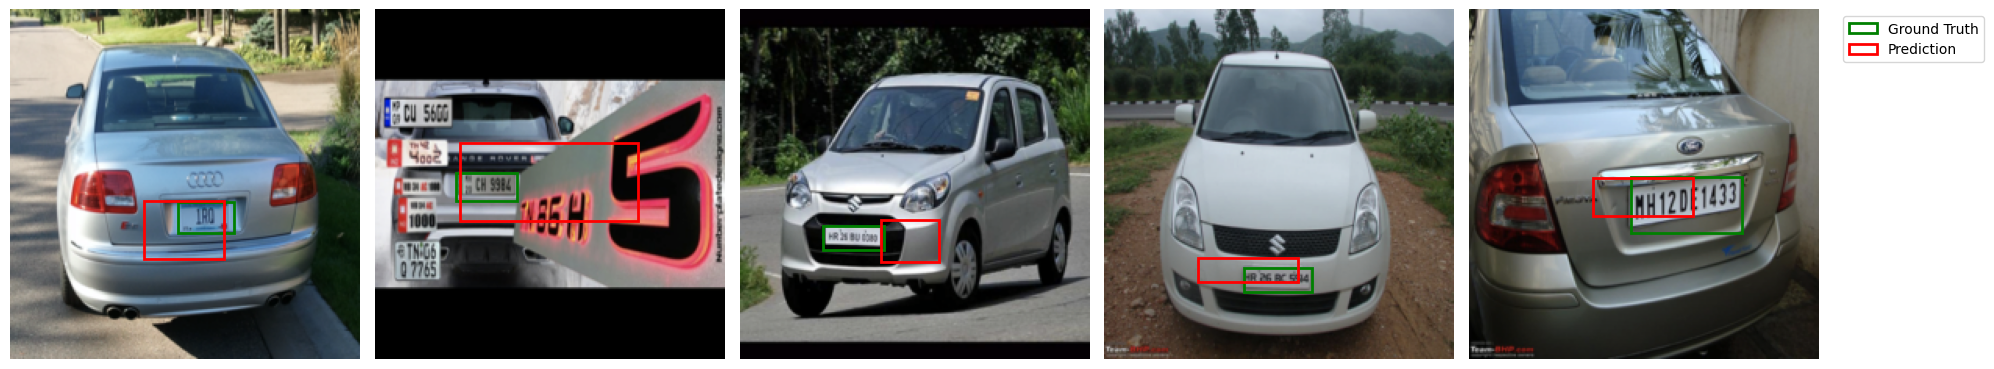

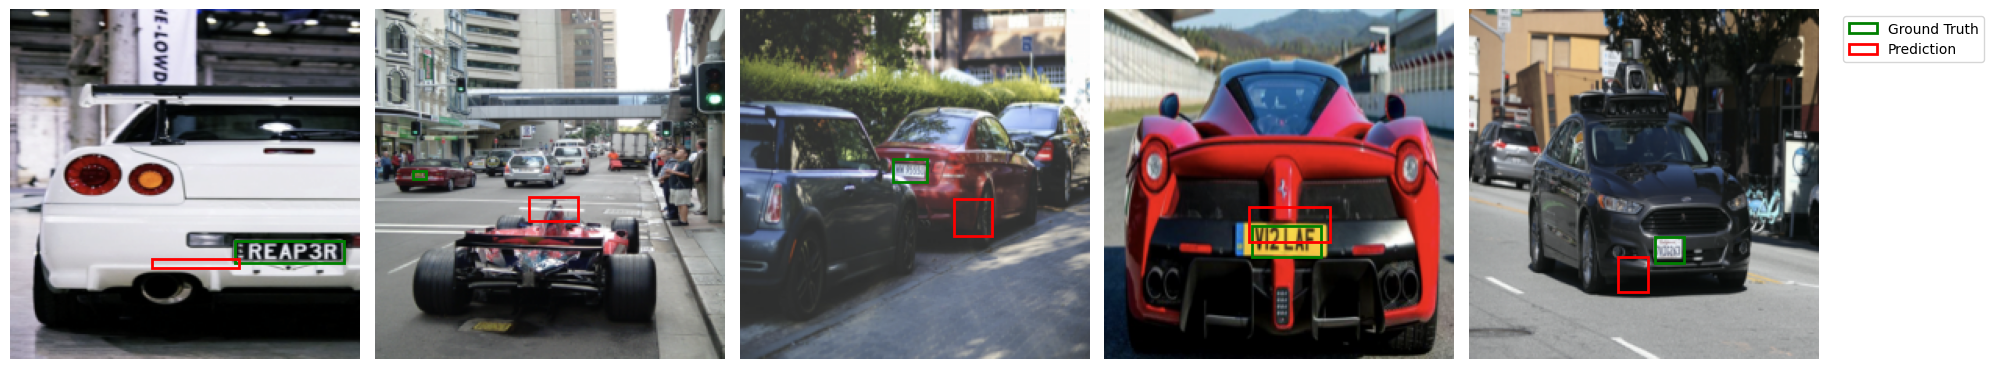

In [25]:
visualize_predictions(val_dataset, model)
visualize_predictions(val_dataset, model, indices=[0, 1, 2, 3, 4])